In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
def load_mnist_data(file_path):
    """
    Load MNIST data from a CSV file.

    Parameters: 
    file_path (str): The path to the CSV file containing MNIST data.    
    """
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    
    # Separate features and labels
    return df

In [3]:
trainData = load_mnist_data('./mnist_train.csv') #from Kaggle

trainData

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59994,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59995,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
def onehot(num):
    encoded = np.zeros((10, 1))
    encoded[num][0] = 1
    return encoded

In [5]:
#load training set
trainLabels = []
trainImages = []
for i in range(trainData.shape[0]):
    dataPoint = trainData.iloc[i].tolist()
    trainLabels.append(onehot(dataPoint[0]))
    trainImages.append(np.array(dataPoint[1:])[:, None])
    

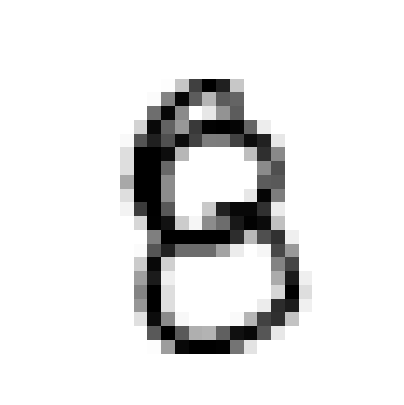

In [6]:
sampleImage = trainImages[np.random.randint(0, trainData.shape[0])]
sampleImageTwoDim = []# for a reproducible, random image
for y in range(28):
    sampleImageTwoDim.append(sampleImage[(y*28):((y+1)*28)])
# 2. Use matplotlib.pyplot.imshow to display this array
plt.figure(figsize=(5, 5))
# cmap='binary' ensures 0 is black and 1 is white, displaying the grid
plt.imshow(sampleImageTwoDim, cmap='binary')

# 3. Remove the axes for a clean, grid-like appearance
plt.axis('off')
plt.show()

In [7]:
#activation function definitions 
relu = lambda X: np.maximum(0, X)
dRelu = lambda X: X>0
# Apply softmax per column (per sample) for batch processing
softmax = lambda z: np.exp(z) / np.sum(np.exp(z), axis=0, keepdims=True)

In [8]:
def forwardProp(x, w1, b1, w2, b2):
    z1 = w1@x+b1
    a1 = relu(z1)
    z2 = w2@a1+b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

In [9]:
def backwardProp(z1, a1, z2, a2, w2, x, y):
    m = x.shape[1]  # batch size
    dz2 = a2 - y
    dw2 = (1/m)*dz2@a1.T
    db2 = (1/m)*np.sum(dz2)
    dz1 = w2.T.dot(dz2)*dRelu(z1)
    dw1 = (1/m)*dz1.dot(x.T)
    db1 = (1/m)*np.sum(dz1)
    return dw1, db1, dw2, db2

In [10]:
def updateParams(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
    w1 -= dw1 * alpha
    w2 -= dw2 * alpha
    b1 -= db1 * alpha
    b2 -= db2 * alpha
    return w1, b1, w2, b2
    

In [11]:
def initParams():
    #using He initialization for ReLU input layer
    fanIn = 784
    w1 = np.random.randn(10, 784)*(np.sqrt(2/fanIn))
    b1 = np.zeros((10, 1))
    w2 = np.random.randn(10, 10)*(np.sqrt(2/fanIn))
    b2 = np.zeros((10, 1))
    return w1, b1, w2, b2

In [12]:
# Verify w1, b1, w2, b2 on test data
testData = load_mnist_data('./mnist_test.csv')
testLabels = []
testImages = []
for i in range(testData.shape[0]):
    dataPoint = testData.iloc[i].tolist()
    testLabels.append(int(dataPoint[0]))
    testImages.append(np.array(dataPoint[1:], dtype=float)[:, None])


In [ ]:
def accuracy(w1, b1, w2, b2):
    X_test = np.hstack(testImages)
    y_true = np.array(testLabels)

    _, _, _, a2 = forwardProp(X_test, w1, b1, w2, b2)
    y_pred = np.argmax(a2, axis=0)

    accuracy = np.mean(y_pred == y_true) * 100
    return accuracy
    
x = np.hstack(trainImages)
y = np.array(trainLabels)
accuracies = []
num_iterations = 1000
def gradientDescent(X_train, Y_train, iterations, alpha):
    w1, b1, w2, b2 = initParams()
    for i in range(iterations):
        z1, a1, z2, a2 = forwardProp(X_train, w1, b1, w2, b2)
        dw1, db1, dw2, db2 = backwardProp(z1, a1, z2, a2, w2, X_train, Y_train)
        w1, b1, w2, b2 = updateParams(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha)
        if i%50 == 0:
            print("iteration: ", i)
            acc = accuracy(w1, b1, w2, b2)
            accuracies.append(acc)
            print("accuracy: ", acc)
gradientDescent(x, y, num_iterations, 0.001)

In [ ]:
# accuracies are logged every 50 iterations (0, 50, 100, ...)
plt.plot(range(0, num_iterations, 50), accuracies)
plt.xlabel('Number of Iterations')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Number of Iterations')
plt.show()

: 